
# SmokeViz Operations Demo
### Given an Area of Interest, Provide Machine Learning Generated Smoke Annotations
---

**Notebook Author:** Rey Koki · rey.koki@noaa.gov  
**Affiliations:**  
1. Cooperative Institute for Research in Environmental Sciences ([CIRES](https://cires.colorado.edu/))  
2. NOAA Global Systems Laboratory ([GSL](https://gsl.noaa.gov/))  



---

### Overview

Given a area of interest (AOI) and datetime, SmokeViz will generate density dependent annotations of smoke.

In [1]:
from einops import rearrange
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(1, './scripts')
import pyproj
from helper_functions import *
from datetime import datetime
import pytz
from Demo_Simplified import *
from Demo_ML import *

#### Set how large/what spatial resolution you'd like to use

In [11]:
img_size = 256 #pixels
res = 1000 #km

# Set Event Specific Parameters

Specify the latitude, longitude and datetime.

### Black Fire (2022)
New Mexico
https://en.wikipedia.org/wiki/Black_Fire_(2022)

['./data/goes/OR_ABI-L1b-RadC-M6C02_G16_s20221550056176_e20221550058549_c20221550058571.nc', './data/goes/OR_ABI-L1b-RadC-M6C01_G16_s20221550056176_e20221550058549_c20221550058590.nc', './data/goes/OR_ABI-L1b-RadC-M6C03_G16_s20221550056176_e20221550058549_c20221550058597.nc']


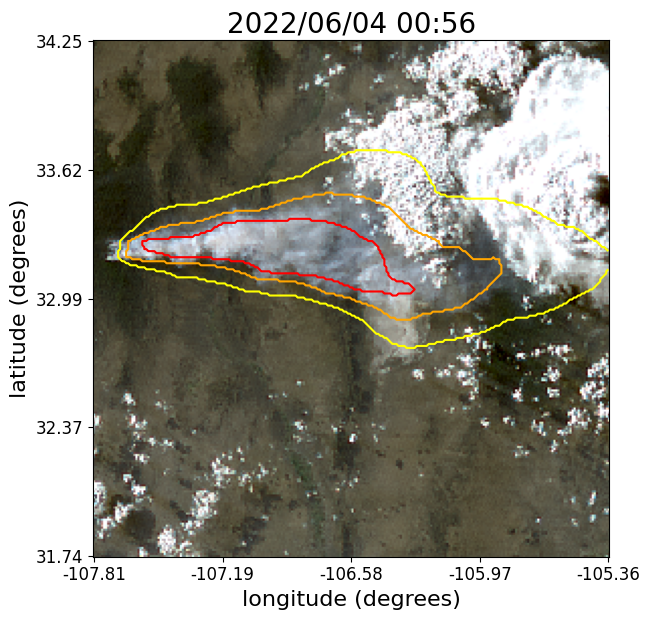

2022/06/04 00:56 (33, -106.6)


In [14]:
# Specify center latitude
lat = '33'
# Specify center longitude
lon = '-106.6'
# Define the target datetime as a string in the format YYYY/MM/DD HH:MM
dt_str = '2022/06/04 00:56'
sat_fns = get_sat_fns(dt_str, lat, lon)
data = create_composite(sat_fns, lat, lon, composites=['cimss_true_color_sunz_rayleigh'], res=res, img_size=img_size)
#plot_data(lat, lon, res, img_size, data, dt_str)
data_loader = get_data_loader(data)
model = get_model()
pred = get_pred(data_loader, model)
plot_data_preds(lat, lon, res, img_size, data, dt_str, pred)

## Camp Fire 2018
https://en.wikipedia.org/wiki/Camp_Fire_(2018)

['./data/goes/OR_ABI-L1b-RadC-M3C03_G16_s20183201617156_e20183201619529_c20183201619572.nc', './data/goes/OR_ABI-L1b-RadC-M3C02_G16_s20183201617156_e20183201619529_c20183201619569.nc', './data/goes/OR_ABI-L1b-RadC-M3C01_G16_s20183201617156_e20183201619529_c20183201619574.nc']


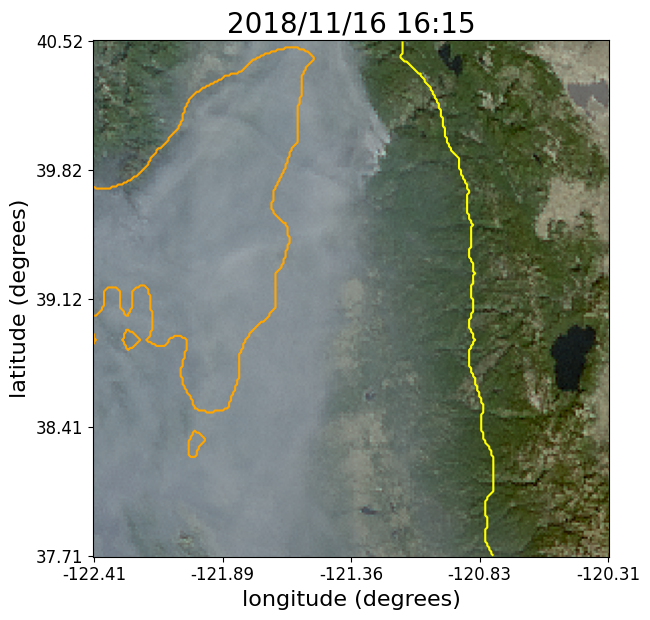

2018/11/16 16:15 (39.12, -121.38)


In [16]:
# Specify center latitude
lat = '39.12'
# Specify center longitude
lon = '-121.38'
# Define the target datetime as a string in the format YYYY/MM/DD HH:MM
dt_str = '2018/11/16 16:15'
sat_fns = get_sat_fns(dt_str, lat, lon)
data = create_composite(sat_fns, lat, lon, composites=['cimss_true_color_sunz_rayleigh'], res=res, img_size=img_size)
data_loader = get_data_loader(data)
model = get_model()
pred = get_pred(data_loader, model)
plot_data_preds(lat, lon, res, img_size, data, dt_str, pred)

## Dixie Fire 2021
https://en.wikipedia.org/wiki/Dixie_Fire

['./data/goes/OR_ABI-L1b-RadC-M6C01_G16_s20211962341194_e20211962343567_c20211962344000.nc', './data/goes/OR_ABI-L1b-RadC-M6C02_G16_s20211962341194_e20211962343567_c20211962343590.nc', './data/goes/OR_ABI-L1b-RadC-M6C03_G16_s20211962341194_e20211962343567_c20211962344009.nc']


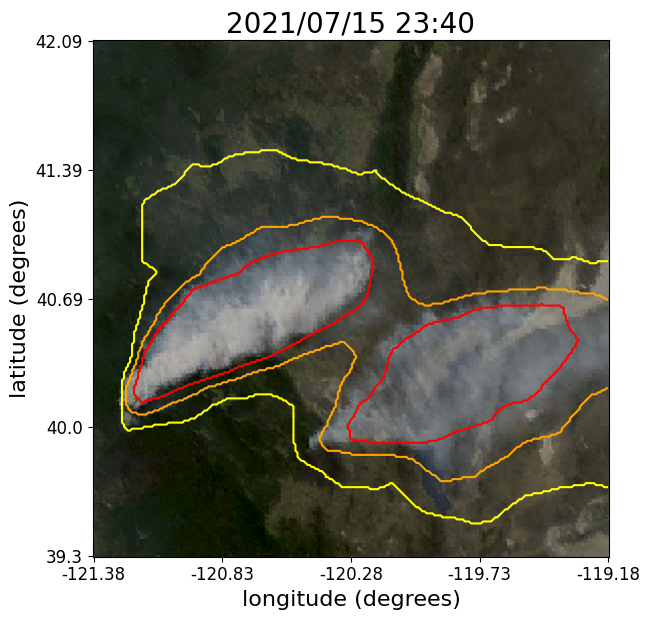

2021/07/15 23:40 (40.7, -120.3)


In [33]:
# Specify center latitude
lat = '40.7'
# Specify center longitude
lon = '-120.3'
# Define the target datetime as a string in the format YYYY/MM/DD HH:MM
dt_str = '2021/07/15 23:40'
sat_fns = get_sat_fns(dt_str, lat, lon)
data = create_composite(sat_fns, lat, lon, composites=['cimss_true_color_sunz_rayleigh'], res=res, img_size=img_size)
data_loader = get_data_loader(data)
model = get_model()
pred = get_pred(data_loader, model)
plot_data_preds(lat, lon, res, img_size, data, dt_str, pred)